## Train

In [8]:
%%capture
import matplotlib.pyplot as plt
from ptycho_torch.inference import reconstruct
from ptycho_torch.train import train

data = "datasets/Run1084_recon3_postPC_shrunk_3.npz"
model = train(data, "outputs/run1084_ffno", {
      "architecture": "ffno",
      "fno_modes": 12,
      "fno_width": 32,
      "fno_blocks": 4,
      "training_groups": 512,
      "nphotons": 1e9,
      "epochs": 50,
  })


## Inference

In [9]:
result = reconstruct(model, data, device = 'cuda')

Calculating dataset length with coordinate bounds...
For file /tmp/barycentric-workspace-li0swgvp/staged/Run1084_recon3_postPC_shrunk_3.npz, maximum x_range is (34.41161595623848, 79.28087207942583), yrange is (35.76291640620743, 79.10709370020433)
Creating memory mapped tensor dictionary...
Memory map length: 722
Memory map creation time: 0.018955469131469727
Populating memory map for dataset 0
Start - end = 722
Non-diffraction memory map write time: 0.057541847229003906
Diffraction memory map write time: 0.010460138320922852
[PtychoDataset Rank 0] Initialization successful. Dataset length: 722.
Reassembly route: barycentric (patch_weighting='probe', varpro_scaling=True)
Using single GPU: cuda
global coords shape: torch.Size([722, 2])
Canvas size: (100, 102), Max offsets: (19, 18)
Batch 1/1: 0.404s (inference: 0.170s, assembly: 0.009s, efficiency: 19.6x)
Initial: s1=1.9347, s2=0.8049
uncorrected scalars: (Parameter containing:
tensor(0.7665, device='cuda:0', dtype=torch.float64, requi

## Plotting

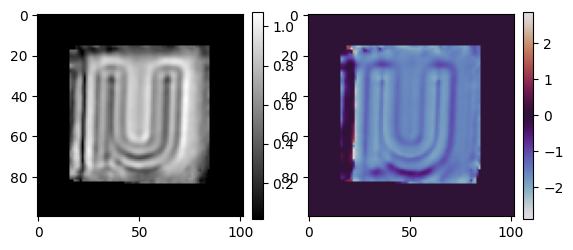

In [10]:
figure, axes = plt.subplots(1, 2)

im0 = axes[0].imshow(result.amplitude, cmap="gray", vmin=0.015)
figure.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(result.phase, cmap="twilight")
figure.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()

### Print configs

In [11]:
from dataclasses import asdict
from pprint import pprint
from ptycho_torch.workflows.components import load_inference_bundle_torch

models, loaded_config = load_inference_bundle_torch(model.parent)
trained_model = models["diffraction_to_obj"]

pprint(asdict(trained_model.model_config))
# pprint(asdict(trained_model.data_config))
#pprint(asdict(trained_model.training_config))
pprint(asdict(trained_model.inference_config))


{'amp_activation': 'silu',
 'amp_loss': None,
 'amp_loss_coeff': 1.0,
 'amplitude_physics_gain': 1.0,
 'architecture': 'ffno',
 'batch_norm': False,
 'cbam_bottleneck': False,
 'cbam_decoder': False,
 'cbam_encoder': True,
 'cnn_output_mode': 'real_imag',
 'convnext_bottleneck_kernel_size': 7,
 'convnext_bottleneck_layerscale_init': 0.1,
 'convnext_bottleneck_mlp_ratio': 4.0,
 'decoder_last_amp_channels': 1,
 'decoder_last_c_outer_fraction': 0.125,
 'decoder_spatial_kernel': 7,
 'eca_decoder': False,
 'eca_encoder': False,
 'edge_pad': 10,
 'ffno_encoder_blocks': 24,
 'ffno_encoder_gate_init': 0.1,
 'ffno_encoder_mlp_ratio': 2.0,
 'ffno_encoder_modes': None,
 'ffno_encoder_norm': 'instance',
 'ffno_encoder_share_weights': True,
 'fno_blocks': 4,
 'fno_cnn_blocks': 2,
 'fno_input_transform': 'none',
 'fno_modes': 12,
 'fno_width': 32,
 'gaussian_smoothing_sigma': 0.0,
 'generator_output_mode': 'real_imag',
 'hybrid_downsample_op': 'stride_conv',
 'hybrid_downsample_steps': 2,
 'hybrid_e

### Setting FFNO params manually